# 01 — LLM Fundamentals

**AI Engineer — hands-on session**

Everything here uses the `openai` library. Nothing else.

> **An LLM is a stateless function: text in, text out.**
> Everything else — memory, tools, RAG — is scaffolding we build around it.

---

### Before you start

Create a free API key at https://console.groq.com/keys

**In the Colab web UI:** open the **🔑 Secrets** panel (key icon, left sidebar), add a secret named `GROQ_API_KEY` and enable *Notebook access*.

**Anywhere else** (VS Code, local Jupyter): set it as an environment variable, or just run the cell — it will prompt you for the key.

In [9]:
%pip install -q --upgrade openai tiktoken "gradio>=5"

> ⚠️ Colab ships an old Gradio. If section 7 raises a `TypeError`, use **Runtime → Restart session** and run the notebook again.

In [ ]:
import getpass
import importlib
import json
import os
import urllib.request

HELPERS_URL = "https://raw.githubusercontent.com/ingmiguelfernando/AIExperiment/main/helpers.py"

# Plotting code lives in helpers.py so it does not get in the way here.
if not os.path.exists(".git"):
    urllib.request.urlretrieve(HELPERS_URL, "helpers.py")

import helpers

importlib.reload(helpers)

### One library, any provider

The `openai` package is not tied to OpenAI. Any provider speaking the same protocol works by changing `base_url`.

We use [Groq](https://groq.com/) here: it runs open models on custom hardware, it is fast, and its free tier is stable enough to demo live.

In [13]:
from openai import OpenAI

# Any provider speaking the same protocol works by swapping these two lines.
BASE_URL = "https://api.groq.com/openai/v1"
MODEL = "openai/gpt-oss-20b"


def get_secret(name):
    """Colab Secrets if available, then an environment variable, then a prompt."""
    try:
        from google.colab import userdata  # type: ignore

        value = userdata.get(name)
        if value:
            return value
    except Exception:
        # Secrets are unreachable when the notebook is driven from VS Code.
        pass

    return os.environ.get(name) or getpass.getpass(f"{name}: ")


client = OpenAI(api_key=get_secret("GROQ_API_KEY"), base_url=BASE_URL)

print("Model:", MODEL)

Model: openai/gpt-oss-20b


### Which models does it actually serve?

Line-ups change constantly, so ask rather than hardcode. Note the speech and safety models in the list — a provider serves more than chat.

In [14]:
for model in sorted(m.id for m in client.models.list().data):
    print(" *" if model == MODEL else "  ", model)

   allam-2-7b
   canopylabs/orpheus-arabic-saudi
   canopylabs/orpheus-v1-english
   meta-llama/llama-prompt-guard-2-22m
   meta-llama/llama-prompt-guard-2-86m
   openai/gpt-oss-120b
 * openai/gpt-oss-20b
   openai/gpt-oss-safeguard-20b
   qwen/qwen3.8-27b
   whisper-large-v3
   whisper-large-v3-turbo


---
## 1. The simplest possible call

A list of messages goes in, one message comes out. That is the entire API.

In [16]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a concise assistant."},
        {"role": "user", "content": "In one sentence, what is the capital of New Zealand?"},
    ],
)

print(response.choices[0].message.content)

The capital of New Zealand is Wellington.


### What it actually returns

The response is more than text. Look at `usage`: **that is what you pay for**.

In [ ]:
print("Model         :", response.model)
print("Finish reason :", response.choices[0].finish_reason)
print("Input tokens  :", response.usage.prompt_tokens)
print("Output tokens :", response.usage.completion_tokens)
print("Total tokens  :", response.usage.total_tokens)

# gpt-oss "thinks" before answering, and those hidden tokens are billed too.
print("\nHidden reasoning:", repr(getattr(response.choices[0].message, "reasoning", None)))

Model         : openai/gpt-oss-20b
Finish reason : stop
Input tokens  : 92
Output tokens : 93
Total tokens  : 185

Hidden reasoning: 'The user asks: "In one sentence, what is the capital of New Zealand?" They want a concise answer: "The capital of New Zealand is Wellington." Probably a one-sentence answer. They also asked earlier: "You are a concise assistant." So keep it short. They want one sentence. So answer: "The capital of New Zealand is Wellington."'


> `gpt-oss-20b` is a **reasoning model**: it writes a private train of thought before the visible answer. You do not see it in the chat, but it is part of `completion_tokens` — you pay for it, and it is why the first call feels slower.

---
## 2. So what is a token?

The model never sees letters, and it never sees words. Text is chopped into **tokens** — frequent chunks of characters — and each one becomes a number.

Rough rule for English: **1 token ≈ 4 characters ≈ ¾ of a word**.

In [17]:
import tiktoken

encoder = tiktoken.get_encoding("o200k_base")

helpers.show_tokens("Wellington is the capital of New Zealand.", encoder)

In [ ]:
print(encoder.encode("Wellington is the capital of New Zealand."))

[54, 78145, 382, 290, 9029, 328, 2036, 24044, 13]


### Not every text costs the same

Watch what happens with another language, with numbers, and with an unusual word.

In [ ]:
helpers.show_tokens("Wellington es la capital de Nueva Zelanda.", encoder)
helpers.show_tokens("Invoice 4829175 total: $1,284.50", encoder)
helpers.show_tokens("antidisestablishmentarianism", encoder)

> The same sentence in Spanish costs more tokens than in English. That is a real cost difference, and it is why non-English apps are more expensive to run.
>
> Notice too that the model never sees individual letters — only these chunks. That is why asking a model to count the letters in a word is a surprisingly hard request.

Try your own text at https://platform.openai.com/tokenizer

---
## 3. Streaming

The model produces **one token at a time**. Streaming does not make it faster: it just lets us watch it happen.

In [19]:
stream = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Describe New Zealand in 3 short bullet points."}],
    stream=True,
)

for chunk in stream:
    piece = chunk.choices[0].delta.content
    if piece:
        print(piece, end="")

- Stunning, rugged landscapes: snow‑capped peaks, fiords, geothermal fields, and golden beaches.  
- A bicultural nation where Māori heritage and English‑speaking society coexist, celebrated in language, art, and governance.  
- Renowned for its outdoors, mild climate, and friendly, innovative spirit.

---
## 4. Where the next token comes from

The model does not write an answer. It writes **one token**, then re-reads everything so far and writes the next one.

To choose each token it gives a score to **every** token in its vocabulary — around 200,000 of them. Suppose it has just read *"The capital of New Zealand is"*. These are the five highest scoring candidates:

/content/helpers.py:51: RuntimeWarning: divide by zero encountered in divide
  if temperature == 0:
/content/helpers.py:52: RuntimeWarning: invalid value encountered in subtract
  # No dice roll at all: the highest score wins every time.


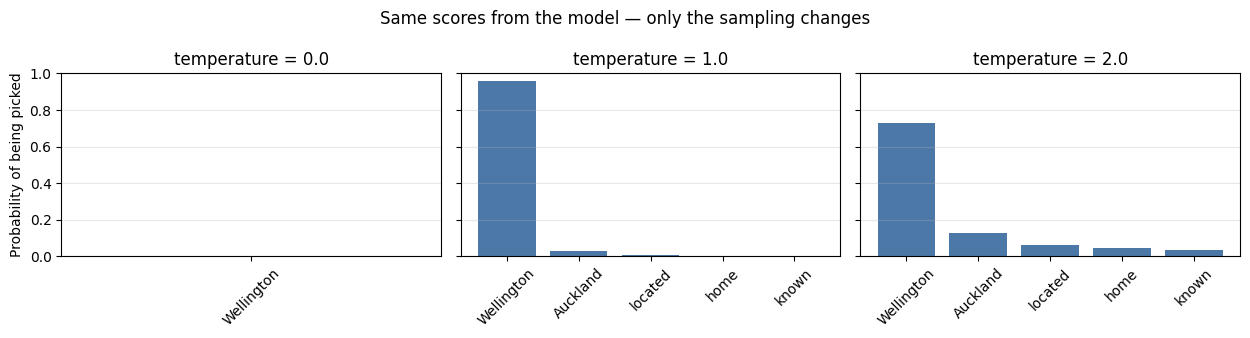

In [22]:
# The top 5 of roughly 200,000 candidates, with the raw scores the model gave them.
candidates = ["Wellington", "Auckland", "located", "home", "known"]
scores = [8.0, 4.5, 3.0, 2.5, 2.0]

helpers.plot_temperature(candidates, scores, temperatures=(0.0, 1.0, 2.0))

**The model's scores never changed** — all three charts come from the same five numbers. **Temperature** is the dial that decides how literally we take them:

| Temperature | What happens |
|---|---|
| `0` | Always take the top score. No dice roll at all — same input, same output. |
| `1` | Roll a dice weighted exactly by the model's scores. |
| `2` | Flatten the odds, so unlikely candidates get a real chance. |

> ### 💡 The bit that is easy to miss
> This dice roll happens **for every single token**, not once per answer. A 200-word reply is this same roll repeated around 260 times.
>
> That is why nudging the temperature does not just change a word — it sends the whole answer down a different path.

Let's see it on a live call. Same prompt four times: twice at `0`, twice at `1.6`.

In [20]:
PROMPT = "Invent a name for a coffee shop in Wellington. Reply with the name only."

for temperature in (0.0, 0.0, 1.6, 1.6):
    result = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": PROMPT}],
        temperature=temperature,
        reasoning_effort="low",  # keep the hidden thinking short so it fits in max_tokens
        max_tokens=512,
    )
    text = (result.choices[0].message.content or "").strip()
    print(f"temperature={temperature} -> {text or '(empty response)'}")

temperature=0.0 -> Brewed Horizons Café
temperature=0.0 -> Brewed Horizons Café
temperature=1.6 -> Whirlwind Brews & Kōrero Café
temperature=1.6 -> Java Bay Beans


> The first two should match, the last two should not.
>
> Two things can spoil it: GPU batching adds a little non-determinism even at temperature 0, and some models ignore the parameter entirely.
>
> With a reasoning model there is a third trap — if the hidden thinking uses up `max_tokens`, the visible answer comes back empty. That is why we cap the reasoning here.

---
## 5. A small experiment

Two calls. Let's start by telling it something about ourselves.

In [ ]:
first = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "My name is Miguel and I'm from Colombia."}],
)

print(first.choices[0].message.content)

¡Hola Miguel! 👋  
Nice to meet you. How can I help you today?


### ❓ Before running the next cell — what will it answer?

In [ ]:
second = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "What is my name?"}],
)

print(second.choices[0].message.content)

I’m not sure—what should I call you? If you’d like, feel free to tell me your name.


It has no idea. **This is not a bug: it is the design.** Every call is independent, like calling a pure function.

The fix? There is no trick. We send everything again:

In [ ]:
conversation = [
    {"role": "user", "content": "My name is Miguel and I'm from Colombia."},
    {"role": "assistant", "content": first.choices[0].message.content},
    {"role": "user", "content": "What is my name?"},
]

third = client.chat.completions.create(model=MODEL, messages=conversation)

print(third.choices[0].message.content)

Your name is Miguel.


> ### 💡 The key idea
> **"Chat" does not exist.** It is a Python list we append to and resend in full on every turn.
>
> What ChatGPT calls *memory* is this loop: store the history, resend it.

Keep this in mind for when we get to RAG.

---
## 6. The cost of remembering

If we resend the whole conversation every turn, then on turn *n* we send *n* messages. The total does not grow in a straight line — it grows **quadratically** (≈ n²/2).

That is why long conversations get slow and expensive, and why a *context window* exists at all.

In [ ]:
turns = [
    "Give me one fun fact about New Zealand.",
    "Another one, please.",
    "One more, different topic.",
    "Another one.",
    "Last one.",
]

messages = [{"role": "system", "content": "Reply in exactly one short sentence."}]
sent_per_turn, cumulative = [], []
total = 0

for turn in turns:
    messages.append({"role": "user", "content": turn})
    result = client.chat.completions.create(model=MODEL, messages=messages)
    messages.append({"role": "assistant", "content": result.choices[0].message.content})

    total += result.usage.total_tokens
    sent_per_turn.append(result.usage.prompt_tokens)
    cumulative.append(total)
    print(f"Turn {len(cumulative)}: sent {result.usage.prompt_tokens:>4} | cumulative {total:>5}")

Turn 1: sent   90 | cumulative   355
Turn 2: sent  126 | cumulative   659
Turn 3: sent  161 | cumulative   993
Turn 4: sent  189 | cumulative  1426
Turn 5: sent  227 | cumulative  1770


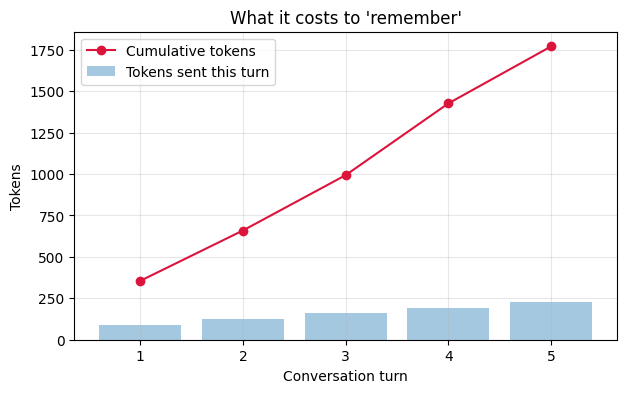

In [ ]:
helpers.plot_token_growth(sent_per_turn, cumulative)

---
## 7. Gradio: the same loop, with a UI

`gr.ChatInterface` keeps the history and hands it back to us as `history`. The function below does exactly what we just did by hand: **concatenate the list and resend it**.

In [ ]:
import inspect

import gradio as gr

print("Gradio", gr.__version__)

# Gradio 5 needs type="messages"; Gradio 6 dropped the argument and always uses that format.
SUPPORTS_TYPE = "type" in inspect.signature(gr.ChatInterface.__init__).parameters

SYSTEM_PROMPT = "You are a helpful assistant. Keep answers short."


def to_messages(history):
    """Older Gradio hands back [user, assistant] pairs, newer versions hand back dicts."""
    if all(isinstance(item, dict) for item in history):
        return [{"role": item["role"], "content": item["content"]} for item in history]

    return [
        {"role": role, "content": text}
        for user_text, assistant_text in history
        for role, text in (("user", user_text), ("assistant", assistant_text))
        if text
    ]


def chat(message, history):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        *to_messages(history),
        {"role": "user", "content": message},
    ]

    stream = client.chat.completions.create(model=MODEL, messages=messages, stream=True)

    partial = ""
    for chunk in stream:
        partial += chunk.choices[0].delta.content or ""
        yield partial


gr.ChatInterface(
    chat,
    title="We are the ones storing the history",
    **({"type": "messages"} if SUPPORTS_TYPE else {}),
).launch()

Gradio 6.28.0
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6e69c6a9af2dd988c1.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## 8. Tools: giving the model hands

Our fictional airline **KiwiAir** has a price list. The model cannot possibly know it — the airline does not exist.

> Not every model supports *function calling*. On Groq's free tier `gpt-oss-20b` does; check your provider's docs before assuming.

### The tool is an ordinary Python function

No AI in here. A dictionary and a lookup — that is all a "tool" ever is.

In [ ]:
TICKET_PRICES = {
    "auckland": 189,
    "christchurch": 159,
    "queenstown": 249,
    "rotorua": 129,
}


def get_ticket_price(destination_city: str) -> dict:
    print(f"   [our code ran] get_ticket_price({destination_city!r})")
    price = TICKET_PRICES.get(destination_city.lower())
    return {"destination_city": destination_city, "price_nzd": price or "unknown"}


get_ticket_price("Queenstown")

   [our code ran] get_ticket_price('Queenstown')


{'destination_city': 'Queenstown', 'price_nzd': 249}

### We describe it to the model

This schema is just text that gets added to the prompt. The model never receives the function — only a description of it.

In [ ]:
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "get_ticket_price",
            "description": "Get the price of a KiwiAir return ticket to a destination city.",
            "parameters": {
                "type": "object",
                "properties": {
                    "destination_city": {
                        "type": "string",
                        "description": "The city the customer wants to fly to",
                    }
                },
                "required": ["destination_city"],
            },
        },
    }
]

messages = [{"role": "user", "content": "How much is a KiwiAir ticket to Queenstown?"}]

first_pass = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
reply = first_pass.choices[0].message

print("Text       :", repr(reply.content))
print("Tool calls :", reply.tool_calls)

Text       : None
Tool calls : [ChatCompletionMessageFunctionToolCall(id='fc_87e7a393-4179-48c3-8e2f-d027d731882a', function=Function(arguments='{"destination_city":"Queenstown"}', name='get_ticket_price'), type='function')]


> ### 💡 The most misunderstood part of all of this
> **Nothing was executed.** The model returned JSON *asking* us to run a function.
>
> Notice there was no `[our code ran]` line above. The model has no hands — it only writes text.

### So we run it, and hand the result back

In [ ]:
AVAILABLE_TOOLS = {"get_ticket_price": get_ticket_price}

messages.append(reply.model_dump(exclude_none=True))

for call in reply.tool_calls or []:
    arguments = json.loads(call.function.arguments)
    observation = AVAILABLE_TOOLS[call.function.name](**arguments)

    messages.append({"role": "tool", "tool_call_id": call.id, "content": json.dumps(observation)})

second_pass = client.chat.completions.create(model=MODEL, messages=messages, tools=TOOLS)
print("\n" + second_pass.choices[0].message.content)

   [our code ran] get_ticket_price('Queenstown')

A KiwiAir return ticket to Queenstown costs **NZD 249**.


### The whole loop, in four steps

1. We send the question **and the menu of available functions**
2. The model replies with JSON: *"call `get_ticket_price` with `Queenstown`"*
3. **Our** code runs the function and appends the result to the message list
4. We call the model again — now the answer is in its context

Every "AI agent" you have heard about is this loop, repeated until the model stops asking for tools.

In [ ]:
for message in messages:
    print(json.dumps(message, indent=2)[:400])
    print("-" * 60)

{
  "role": "user",
  "content": "How much is a KiwiAir ticket to Queenstown?"
}
------------------------------------------------------------
{
  "role": "assistant",
  "tool_calls": [
    {
      "id": "fc_87e7a393-4179-48c3-8e2f-d027d731882a",
      "function": {
        "arguments": "{\"destination_city\":\"Queenstown\"}",
        "name": "get_ticket_price"
      },
      "type": "function"
    }
  ],
  "reasoning": "We need to call the function get_ticket_price with destination_city \"Queenstown\"."
}
------------------------------------------------------------
{
  "role": "tool",
  "tool_call_id": "fc_87e7a393-4179-48c3-8e2f-d027d731882a",
  "content": "{\"destination_city\": \"Queenstown\", \"price_nzd\": 249}"
}
------------------------------------------------------------


### Plan B: the same idea without `tools`

Before `tools` existed, everyone did this by hand: describe the format in the prompt and parse whatever comes back.

It proves that **`tools` is mostly syntactic sugar over "reply in this format"** — and it shows why the sugar is worth having.

In [ ]:
from openai import BadRequestError

INSTRUCTIONS = (
    "You are a routing layer, not an assistant.\n"
    "If the user asks about a ticket price, reply with exactly this and nothing else:\n"
    '{"action": "lookup_price", "destination_city": "<city>"}\n'
    "Otherwise reply with plain text."
)
QUESTION = "How much does it cost to fly to Rotorua?"

try:
    raw = (
        client.chat.completions.create(
            model=MODEL,
            messages=[
                {"role": "system", "content": INSTRUCTIONS},
                {"role": "user", "content": QUESTION},
            ],
            temperature=0,
        )
        .choices[0]
        .message.content
        or ""
    ).strip()
except BadRequestError as error:
    # Models trained on function calling sometimes emit a tool call even when we offered no tools.
    raw = ""
    print("The provider rejected the reply:", error.message)

print("The model replied:", raw)

try:
    instruction = json.loads(raw)
except json.JSONDecodeError:
    print("\nNot usable JSON — this is exactly the fragility that `tools` removes.")
else:
    observation = get_ticket_price(instruction["destination_city"])

    final = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "user", "content": QUESTION},
            {"role": "user", "content": f"Price data: {json.dumps(observation)}. Answer in one sentence."},
        ],
    )
    print("\n" + final.choices[0].message.content)

The model replied: {"action":"lookup_price","destination_city":"Rotorua"}
   [our code ran] get_ticket_price('Rotorua')

It costs NZD 129 to fly to Rotorua.


---
## Recap

| What it looks like | What it really is |
|---|---|
| The model reads my words | It reads token numbers, and cannot see letters |
| The chatbot remembers me | We resend the full list every single turn |
| The model is creative | It samples from a probability distribution |
| The model looked something up | It returned JSON and *our* code made the call |

It all comes down to **what text we put in the prompt**.

Which is the next problem: context is finite, and you pay for it by the token. We cannot paste a company's entire documentation into every question.

➡️ **Continues in `02_rag.ipynb`**